# Analyze Distribution

In [3]:
import pandas as pd

df = pd.read_csv(
    '/Users/anapreciado/Desktop/github_repos/dataccion-agent/extraction/data/EMP_TEMP_SEX_ECO_NB_A-remodelado-2026-04-04.csv'
)

In [4]:
df

,Área de referencia,Fuente,Actividad económica,Año,Mujeres,Hombres
0,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Total,2024,5927.0,7408.4
1,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",A. Agricultura; ganadería; silvicultura y pesca,2024,19.2,61.5
2,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",B. Explotación de minas y canteras,2024,9.9,54.9
3,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",C. Industrias manufactureras,2024,449.0,961.9
4,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano","D. Suministro de electricidad, gas; vapor y ai...",2024,9.7,43.5
...,...,...,...,...,...,...
538,Uruguay,EFT - Encuesta Continua de Hogares,Q. Actividades de atención de la salud humana ...,2024,117.1,39.0
539,Uruguay,EFT - Encuesta Continua de Hogares,"R. Actividades artísticas, de entretenimiento ...",2024,10.8,21.2
540,Uruguay,EFT - Encuesta Continua de Hogares,S. Otras actividades de servicios,2024,34.8,22.9
541,Uruguay,EFT - Encuesta Continua de Hogares,T. Actividades de los hogares como empleadores...,2024,84.7,10.1


## Segregación horizontal por género y actividad económica

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# --- Prep ---
# Drop "Total" rows and rows with all-NaN values
df_act = df[df['Actividad económica'] != 'Total'].dropna(subset=['Mujeres', 'Hombres']).copy()

# Short label: letter code only (A, B, C, …)
df_act['Código'] = df_act['Actividad económica'].str.extract(r'^([A-Z](?:\d+)?)\.')

# Full short label for tooltips/legend
df_act['Etiqueta'] = df_act['Actividad económica'].str.slice(0, 55)

# Female share (%) out of total employed in that sector
df_act['Total_sector'] = df_act['Mujeres'] + df_act['Hombres']
df_act['Pct_mujeres'] = df_act['Mujeres'] / df_act['Total_sector'] * 100
df_act['Pct_hombres'] = df_act['Hombres'] / df_act['Total_sector'] * 100

countries = df_act['Área de referencia'].unique()
print(f"Países: {list(countries)}")
print(f"Actividades únicas: {df_act['Código'].nunique()}")
df_act.head()

Países: ['Argentina', 'Bahamas', 'Belice', 'Bolivia (Estado Plurinacional de)', 'Brasil', 'Barbados', 'Chile', 'Colombia', 'Costa Rica', 'Islas Caimán', 'República Dominicana', 'Ecuador', 'Granada', 'Guatemala', 'Guyana', 'Honduras', 'Jamaica', 'Santa Lucía', 'México', 'Panamá', 'Perú', 'El Salvador', 'Suriname', 'Trinidad y Tabago', 'Uruguay']
Actividades únicas: 22


,Área de referencia,Fuente,Actividad económica,Año,Mujeres,Hombres,Código,Etiqueta,Total_sector,Pct_mujeres,Pct_hombres
1,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",A. Agricultura; ganadería; silvicultura y pesca,2024,19.2,61.5,A,A. Agricultura; ganadería; silvicultura y pesca,80.7,23.791822,76.208178
2,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",B. Explotación de minas y canteras,2024,9.9,54.9,B,B. Explotación de minas y canteras,64.8,15.277778,84.722222
3,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",C. Industrias manufactureras,2024,449.0,961.9,C,C. Industrias manufactureras,1410.9,31.823659,68.176341
4,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano","D. Suministro de electricidad, gas; vapor y ai...",2024,9.7,43.5,D,"D. Suministro de electricidad, gas; vapor y ai...",53.2,18.233083,81.766917
5,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",E. Suministro de agua; evacuación de aguas res...,2024,16.2,77.0,E,E. Suministro de agua; evacuación de aguas res...,93.2,17.381974,82.618026


### 1. Gráfico de mariposa: distribución por género y actividad (por país)

Cada barra muestra el porcentaje de mujeres (izquierda, rosa) y hombres (derecha, azul) en cada sector. La línea punteada en 50 % indica paridad.

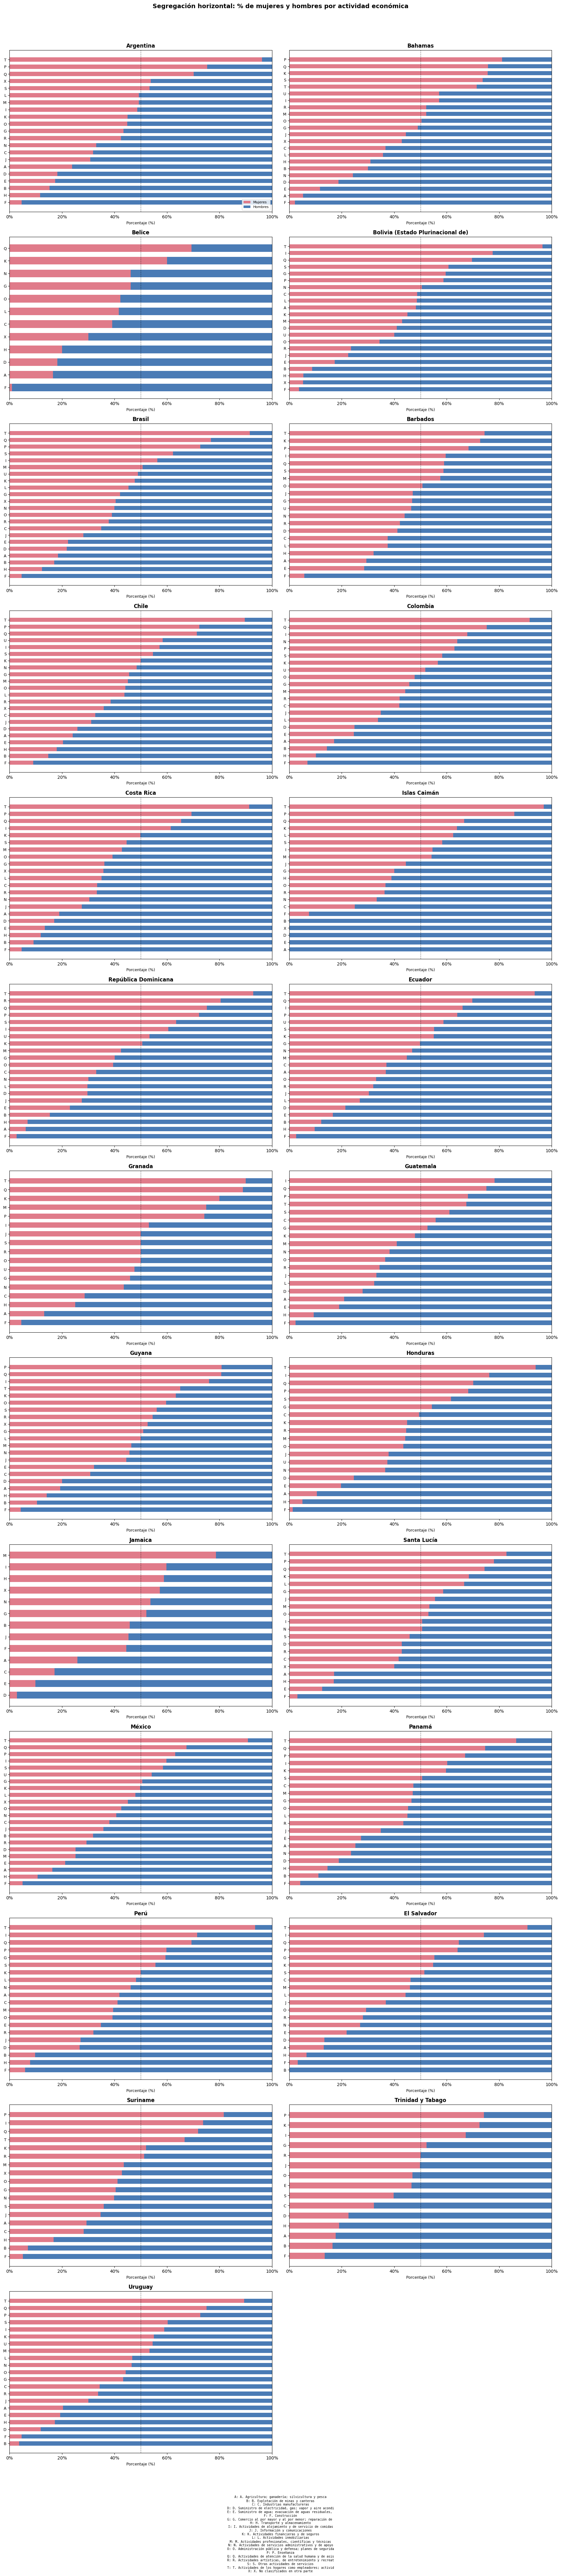

In [13]:
COLOR_F = '#E07B8A'   # women – pink/red
COLOR_M = '#4A7BB5'  # men  – blue

ncols = 2
nrows = int(np.ceil(len(countries) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 6))
axes = axes.flatten()

for ax, country in zip(axes, countries):
    sub = df_act[df_act['Área de referencia'] == country].copy()
    # Sort by female share so most female-dominated sectors appear at top
    sub = sub.sort_values('Pct_mujeres', ascending=True)
    y = np.arange(len(sub))

    ax.barh(y, sub['Pct_mujeres'], color=COLOR_F, label='Mujeres', height=0.6)
    ax.barh(y, sub['Pct_hombres'], left=sub['Pct_mujeres'], color=COLOR_M, label='Hombres', height=0.6)

    ax.axvline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xlim(0, 100)
    ax.set_yticks(y)
    ax.set_yticklabels(sub['Código'], fontsize=9)
    ax.set_xlabel('Porcentaje (%)', fontsize=9)
    ax.set_title(country, fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    if ax == axes[0]:
        ax.legend(loc='lower right', fontsize=8)

# Hide unused subplots
for ax in axes[len(countries):]:
    ax.set_visible(False)

# Build legend for activity codes (use first country as reference)
ref = df_act[df_act['Área de referencia'] == countries[0]][['Código', 'Etiqueta']].drop_duplicates().sort_values('Código')
legend_text = '\n'.join(f"{row['Código']}: {row['Etiqueta']}" for _, row in ref.iterrows())
fig.text(0.5, -0.01, legend_text, ha='center', va='top', fontsize=7,
         family='monospace', wrap=True)

fig.suptitle('Segregación horizontal: % de mujeres y hombres por actividad económica',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('horizontal_segregation_butterfly.png', dpi=150, bbox_inches='tight')
plt.show()

### 2. Mapa de calor: proporción de mujeres (%) por país y actividad

Valores > 50 % (tonos verdes) indican sectores feminizados; valores < 50 % (tonos rojos) indican sectores masculinizados.

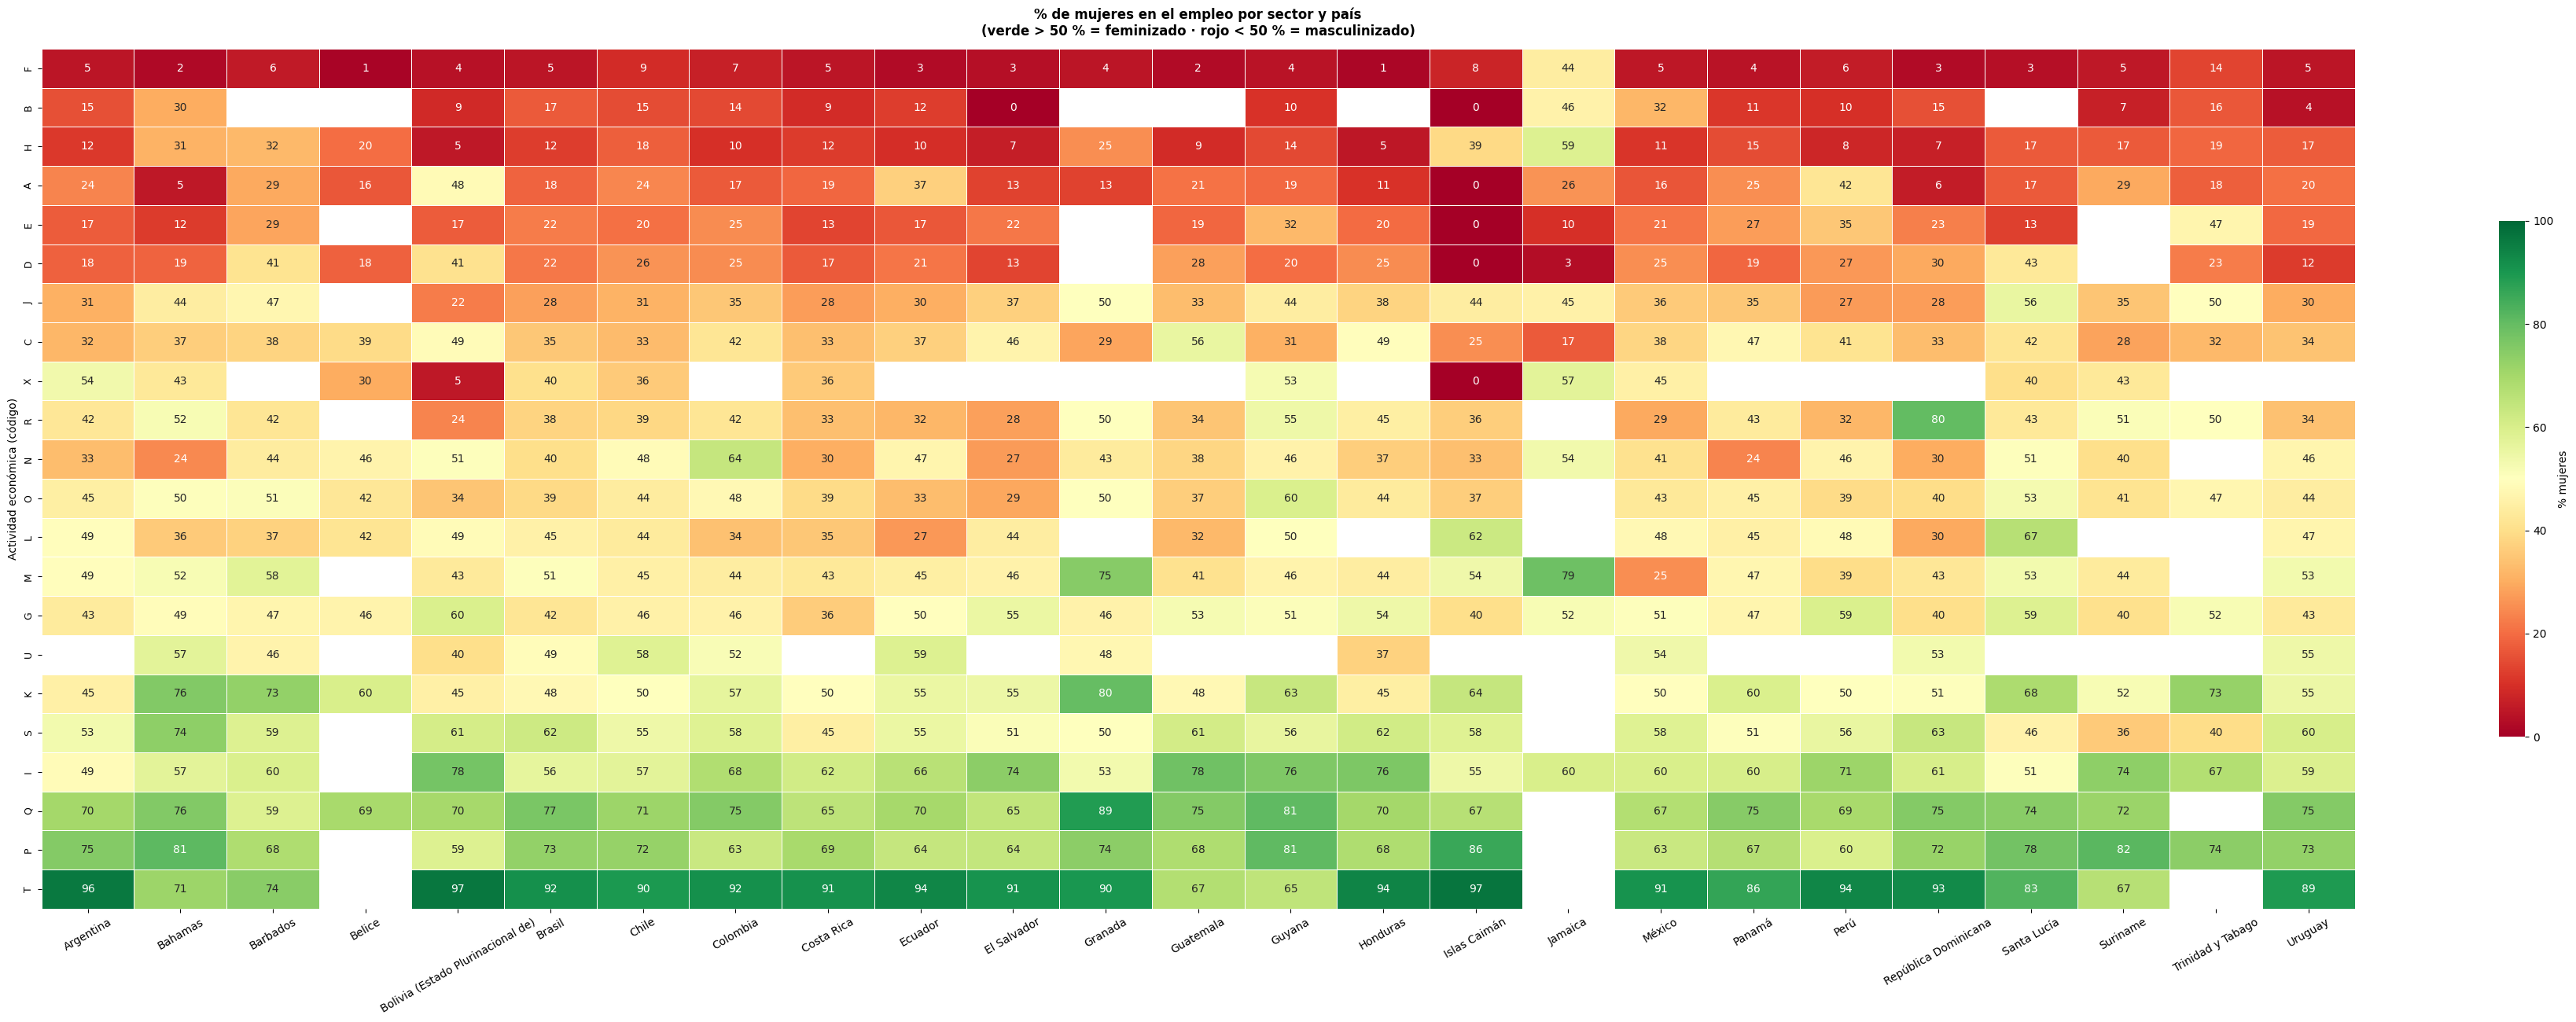

In [7]:
# Pivot: rows = activity code, columns = country
pivot = df_act.pivot_table(
    index='Código', columns='Área de referencia', values='Pct_mujeres', aggfunc='mean'
)
# Sort rows by median female share across countries
pivot = pivot.loc[pivot.median(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(max(8, len(countries) * 1.5), len(pivot) * 0.55 + 1))

sns.heatmap(
    pivot,
    annot=True, fmt='.0f',
    cmap='RdYlGn',        # red = male-dominated, green = female-dominated
    center=50,
    vmin=0, vmax=100,
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': '% mujeres', 'shrink': 0.6},
    ax=ax
)

ax.set_xlabel('')
ax.set_ylabel('Actividad económica (código)', fontsize=10)
ax.set_title('% de mujeres en el empleo por sector y país\n(verde > 50 % = feminizado · rojo < 50 % = masculinizado)',
             fontsize=12, fontweight='bold', pad=12)
ax.tick_params(axis='x', labelsize=10, rotation=30)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('horizontal_segregation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Índice de segregación por actividad (promedio regional)

Distancia respecto a la paridad (50 %): valores positivos = sectores feminizados, negativos = masculinizados.

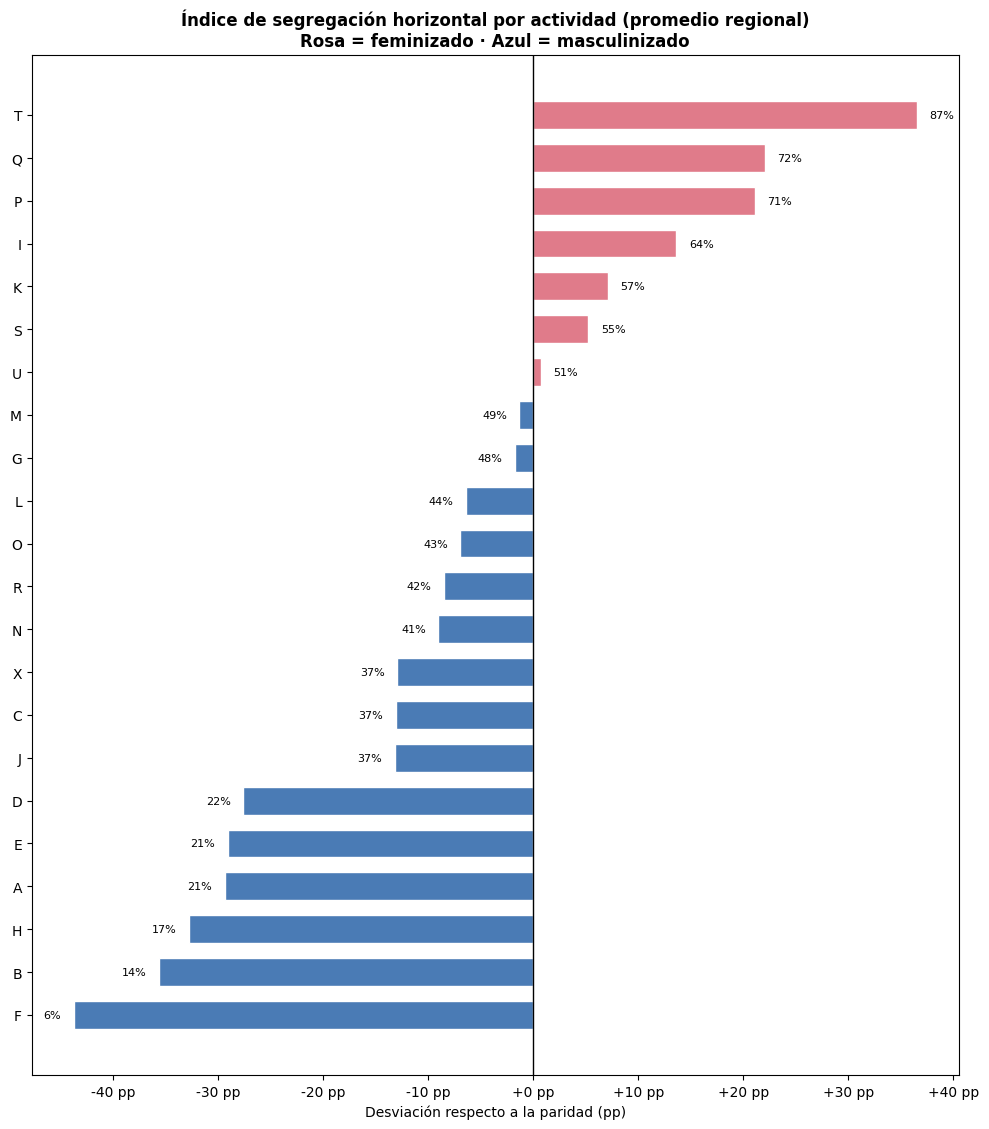


Actividades más feminizadas (promedio regional):
Código                                                Etiqueta  Pct_mujeres_media
     K                 K. Actividades financieras y de seguros          57.108151
     I  I. Actividades de alojamiento y de servicio de comidas          63.598455
     P                                            P. Enseñanza          71.068498
     Q Q. Actividades de atención de la salud humana y de asis          72.019103
     T T. Actividades de los hogares como empleadores; activid          86.500623

Actividades más masculinizadas (promedio regional):
Código                                                Etiqueta  Pct_mujeres_media
     F                                         F. Construcción           6.263035
     B                      B. Explotación de minas y canteras          14.363426
     H                          H. Transporte y almacenamiento          17.198912
     A         A. Agricultura; ganadería; silvicultura y pesca          20.62

In [8]:
# Mean female share per activity across all countries
seg = (
    df_act.groupby(['Código', 'Etiqueta'])['Pct_mujeres']
    .mean()
    .reset_index()
    .rename(columns={'Pct_mujeres': 'Pct_mujeres_media'})
)
seg['Desviación_paridad'] = seg['Pct_mujeres_media'] - 50
seg = seg.sort_values('Desviación_paridad')

colors = [COLOR_F if v > 0 else COLOR_M for v in seg['Desviación_paridad']]

fig, ax = plt.subplots(figsize=(10, len(seg) * 0.45 + 1.5))
bars = ax.barh(seg['Código'], seg['Desviación_paridad'], color=colors, height=0.65, edgecolor='white')

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Desviación respecto a la paridad (pp)', fontsize=10)
ax.set_title('Índice de segregación horizontal por actividad (promedio regional)\n'
             'Rosa = feminizado · Azul = masculinizado', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f pp'))

# Annotate with mean % value
for bar, val, pct in zip(bars, seg['Desviación_paridad'], seg['Pct_mujeres_media']):
    xpos = val + (1.2 if val >= 0 else -1.2)
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{pct:.0f}%', va='center', ha=ha, fontsize=8)

plt.tight_layout()
plt.savefig('horizontal_segregation_index.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nActividades más feminizadas (promedio regional):")
print(seg.tail(5)[['Código', 'Etiqueta', 'Pct_mujeres_media']].to_string(index=False))
print("\nActividades más masculinizadas (promedio regional):")
print(seg.head(5)[['Código', 'Etiqueta', 'Pct_mujeres_media']].to_string(index=False))

### 4. Variabilidad entre países: ¿qué sectores muestran más dispersión?

Un sector con alta desviación estándar entre países indica que la segregación no es homogénea en la región.

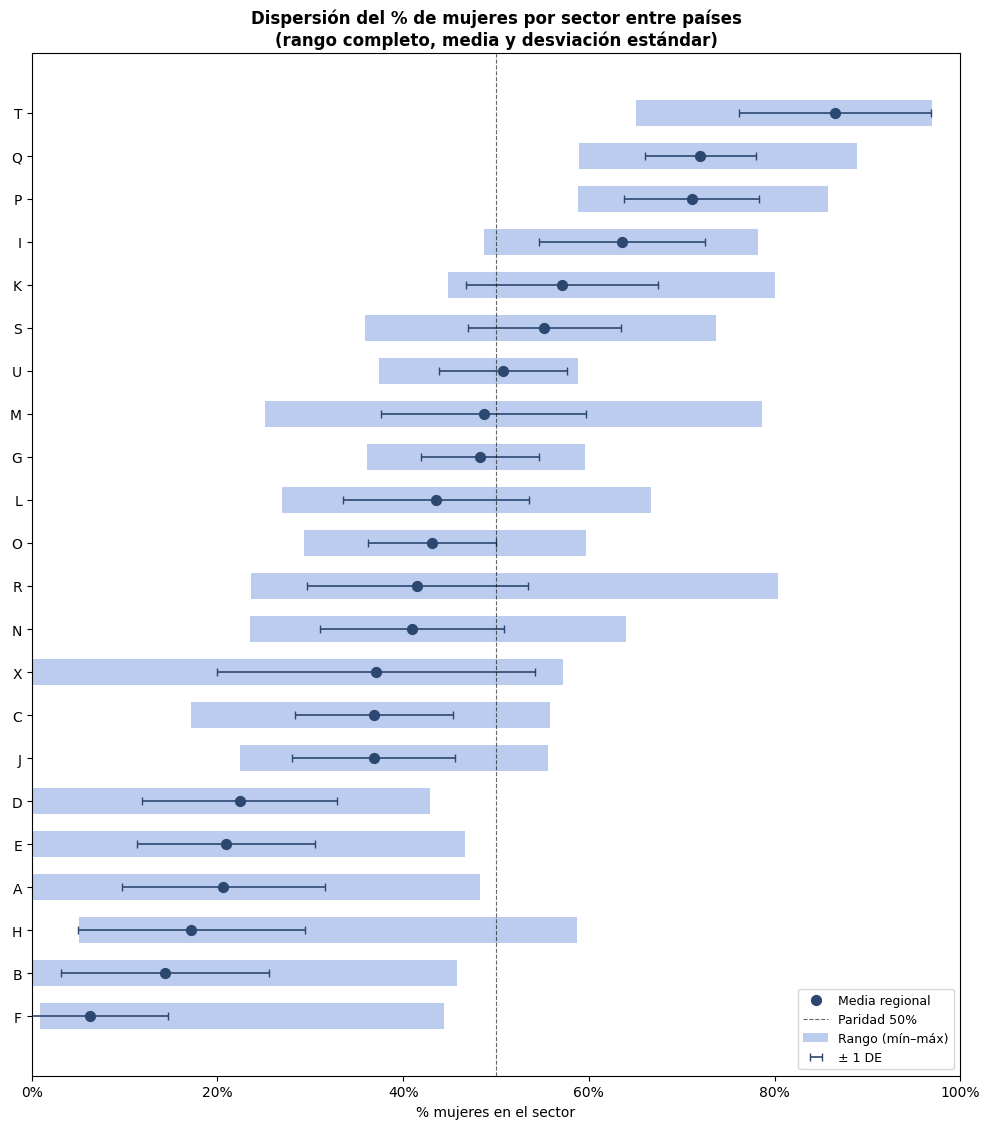

Código     media       std       min       max
     X 37.063748 17.131164  0.000000 57.264231
     H 17.198912 12.220597  5.059733 58.766234
     R 41.517021 11.899746 23.581560 80.413555
     B 14.363426 11.158784  0.000000 45.754717
     M 48.681178 11.029255 25.102123 78.672316
     A 20.625796 10.926544  0.000000 48.261694
     D 22.390112 10.484522  0.000000 42.857143
     K 57.108151 10.384815 44.871795 80.000000
     T 86.500623 10.338837 65.079365 96.969697
     L 43.554656 10.041136 26.907631 66.666667
     N 40.966457  9.889303 23.522013 63.964951
     E 20.898457  9.570990  0.000000 46.621622
     I 63.598455  8.951140 48.725806 78.219361
     J 36.831023  8.798153 22.437673 55.555556
     C 36.899274  8.517793 17.105263 55.838310
     F  6.263035  8.372075  0.877193 44.444444
     S 55.221361  8.287781 35.897436 73.684211
     P 71.068498  7.276457 58.782201 85.714286
     O 43.066517  6.902777 29.277286 59.661017
     U 50.717657  6.896943 37.396122 58.823529
     G 48.269

In [9]:
stats = (
    df_act.groupby('Código')['Pct_mujeres']
    .agg(media='mean', std='std', min='min', max='max')
    .reset_index()
    .sort_values('media')
)

fig, ax = plt.subplots(figsize=(10, len(stats) * 0.45 + 1.5))

# Range bar (min–max)
ax.barh(stats['Código'], stats['max'] - stats['min'],
        left=stats['min'], color='#BBCCEE', height=0.6, label='Rango (mín–máx)')

# Mean marker
ax.scatter(stats['media'], stats['Código'],
           color='#2C4770', zorder=5, s=50, label='Media regional')

# Std error bars
ax.errorbar(stats['media'], stats['Código'],
            xerr=stats['std'], fmt='none', color='#2C4770',
            capsize=3, linewidth=1.2, label='± 1 DE')

ax.axvline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.6, label='Paridad 50%')
ax.set_xlim(0, 100)
ax.set_xlabel('% mujeres en el sector', fontsize=10)
ax.set_title('Dispersión del % de mujeres por sector entre países\n(rango completo, media y desviación estándar)',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('horizontal_segregation_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()

print(stats.sort_values('std', ascending=False).to_string(index=False))